# Hindi Song Mood Classifier — Full Experimental Report

**A step-by-step ML engineering journey: Logistic Regression → Classical ML → Deep Learning → Negative result (Essentia)**

---

**Dataset:** ~1,700 Hindi film songs · 50+ Librosa audio features (MFCCs, chroma, spectral, tempo)  
**Task:** Multiclass mood classification — `happy`, `sad`, `romantic`, `excited`, `other`  
**Final best:** TabTransformer · `remove_other+undersample` · **Accuracy 62.85% · F1-macro 0.6116**

---

### Notebook Structure

| Phase | What we did | Why |
|-------|-------------|-----|
| **1** | Logistic Regression baseline (5 classes) | Standard interpretable first model |
| **2** | Confusion matrix analysis | Diagnose which classes fail and why |
| **3** | Remove `other` class | Catch-all with no acoustic signature corrupts all boundaries |
| **4** | SMOTE & undersampling | `happy` still weak — address imbalance |
| **5** | Learning curve | Decide: more data or better model? |
| **6** | Classical ML sweep (RF, XGBoost, SVM, LDA, LightGBM...) | LR's linear boundary is limiting |
| **7** | Deep learning (MLP, TabNet, TabTransformer) | Classical ML plateaus at 60%; attention captures feature interactions |
| **8** | Essentia high-level features — *negative result* | Western pre-trained models fail on Hindi music |


## Setup — Imports & Configuration

In [12]:
# Install dependencies (run once)
# !pip install xgboost lightgbm imbalanced-learn scikit-learn pandas matplotlib seaborn openpyxl pytorch-tabnet torch

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import product

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from pytorch_tabnet.tab_model import TabNetClassifier

RANDOM_STATE = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("All imports OK")
print(f"PyTorch device: {DEVICE}")


All imports OK
PyTorch device: cpu


## Data Loading & EDA

We extracted 50+ features per song using **Librosa**:
- **MFCCs 1–20** — timbre/tonal envelope; most informative for mood
- **Chroma features** — pitch class profiles; harmonic content
- **Spectral features** — centroid, rolloff, bandwidth, contrast, flatness
- **Tempo, rhythm, RMS, ZCR** — energy, loudness, texture

Labels were assigned via majority-vote of ChatGPT, Claude, and DeepSeek, then manually reviewed.


In [ ]:
EXCEL_PATH = "without_essentia.xlsx"
TARGET_COL = "FINAL MOOD"
META_COLS  = ["ID", "Song Title", "Film / Album", "Year",
              "ChatGPT Mood", "Claude Mood", "deepseek/copilot Mood",
              "FINAL MOOD", "Test", "File name"]

df = pd.read_excel(EXCEL_PATH)
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]

print(f"Dataset shape   : {df.shape}")
print(f"Feature columns : {len(FEATURE_COLS)}")
print()
print("Class distribution:")
print(df[TARGET_COL].value_counts().to_string())


Dataset shape   : (1606, 61)
Feature columns : 51

Class distribution:
FINAL MOOD
romantic    398
other       345
sad         340
excited     325
happy       198


### Fig 1 — Class Distribution

The first thing an ML engineer does: understand the data. We need to know class imbalance before choosing a loss function, evaluation metric, or sampling strategy.

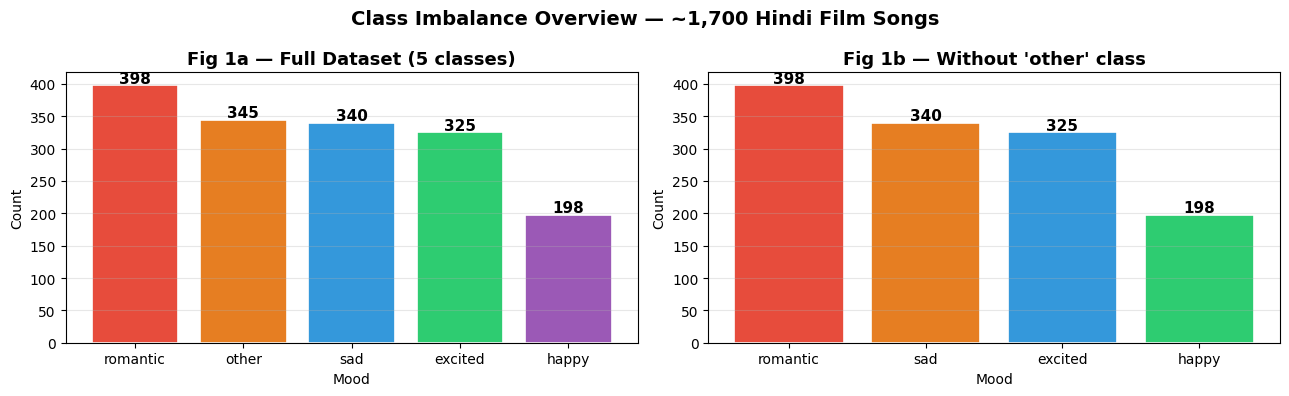

Key: 'happy' = 198 samples vs 'romantic' = 398 (~2x imbalance)
'other' = bhajans, devotional, misc — no coherent acoustic category


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts  = df[TARGET_COL].value_counts()
colors  = ["#e74c3c", "#e67e22", "#3498db", "#2ecc71", "#9b59b6"]

axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=1.2)
axes[0].set_title("Fig 1a — Full Dataset (5 classes)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Mood"); axes[0].set_ylabel("Count")
for i,(cls,v) in enumerate(counts.items()):
    axes[0].text(i, v+4, str(v), ha="center", fontsize=11, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

counts_no = df.loc[df[TARGET_COL]!="other", TARGET_COL].value_counts()
axes[1].bar(counts_no.index, counts_no.values, color=colors[:4], edgecolor="white", linewidth=1.2)
axes[1].set_title("Fig 1b — Without 'other' class", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Mood"); axes[1].set_ylabel("Count")
for i,(cls,v) in enumerate(counts_no.items()):
    axes[1].text(i, v+4, str(v), ha="center", fontsize=11, fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Class Imbalance Overview — ~1,700 Hindi Film Songs", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig1_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Key: 'happy' = {counts.get('happy','?')} samples vs 'romantic' = {counts.get('romantic','?')} (~2x imbalance)")
print(f"'other' = bhajans, devotional, misc — no coherent acoustic category")


### Feature Selection — Remove Low-Variance & Highly Correlated Features

MFCCs are inherently correlated (adjacent coefficients overlap in frequency). We apply two filters before any modelling.

In [15]:
def drop_low_variance(X_df, threshold=0.01):
    scaled = pd.DataFrame(MinMaxScaler().fit_transform(X_df), columns=X_df.columns)
    return [c for c in scaled.columns if scaled[c].var() > threshold]

def drop_correlated(X_df, threshold=0.90):
    corr  = X_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop  = {c for c in upper.columns if any(upper[c] > threshold)}
    return [c for c in X_df.columns if c not in drop]

X_full = df[FEATURE_COLS].copy()
n_orig = X_full.shape[1]
keep   = drop_low_variance(X_full); X_full = X_full[keep]
keep   = drop_correlated(X_full);   X_full = X_full[keep]

print(f"Features before : {n_orig}")
print(f"Features after  : {X_full.shape[1]}  (removed {n_orig - X_full.shape[1]} redundant features)")

y_full    = df[TARGET_COL].values
INPUT_DIM = X_full.shape[1]

# ── Shared data preparation helper (used throughout the notebook) ─────────
def prepare_data(strategy, X, y):
    if "remove_other" in strategy:
        mask = y != "other"; X_use, y_use = X[mask], y[mask]
    else:
        X_use, y_use = X.copy(), y.copy()
    le    = LabelEncoder()
    y_enc = le.fit_transform(y_use)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_use.values, y_enc, test_size=0.2, stratify=y_enc, random_state=RANDOM_STATE)
    if "oversample"   in strategy: X_tr, y_tr = SMOTE(random_state=RANDOM_STATE).fit_resample(X_tr, y_tr)
    elif "undersample" in strategy: X_tr, y_tr = RandomUnderSampler(random_state=RANDOM_STATE).fit_resample(X_tr, y_tr)
    return X_tr, X_te, y_tr, y_te, le


Features before : 51
Features after  : 28  (removed 23 redundant features)


---
## Phase 1 — Logistic Regression Baseline (All 5 Classes)

**Why LR first?**  
Logistic Regression with `class_weight='balanced'` is the canonical starting point for multiclass text/audio classification:
- Fast and interpretable — coefficients show which features pull toward each mood
- If LR works well, the problem is linearly separable and simpler models suffice
- If LR fails, it tells us *exactly why* (via confusion matrix) rather than just "bad accuracy"

This baseline gives us the two problems we will solve in Phases 3 and 4.


In [16]:
X_tr_b, X_te_b, y_tr_b, y_te_b, le_b = prepare_data("baseline", X_full, y_full)

lr_base = Pipeline([
    ("sc",  StandardScaler()),
    ("clf", LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced",
                               random_state=RANDOM_STATE))
])
lr_base.fit(X_tr_b, y_tr_b)
y_pred_lr = lr_base.predict(X_te_b)

acc_lr = accuracy_score(y_te_b, y_pred_lr)
f1_lr  = f1_score(y_te_b, y_pred_lr, average="macro")

print("=" * 55)
print("PHASE 1 — Logistic Regression Baseline (5 classes)")
print("=" * 55)
print(f"Accuracy : {acc_lr:.4f}")
print(f"F1-macro : {f1_lr:.4f}")
print()
print(classification_report(y_te_b, y_pred_lr, target_names=le_b.classes_))


PHASE 1 — Logistic Regression Baseline (5 classes)
Accuracy : 0.4472
F1-macro : 0.4360

              precision    recall  f1-score   support

     excited       0.69      0.74      0.71        65
       happy       0.25      0.30      0.27        40
       other       0.43      0.48      0.45        69
    romantic       0.38      0.29      0.33        80
         sad       0.42      0.41      0.42        68

    accuracy                           0.45       322
   macro avg       0.43      0.44      0.44       322
weighted avg       0.44      0.45      0.44       322



### Fig 2 — Baseline Confusion Matrix

This is the key diagnostic tool. We read off two specific problems from it.

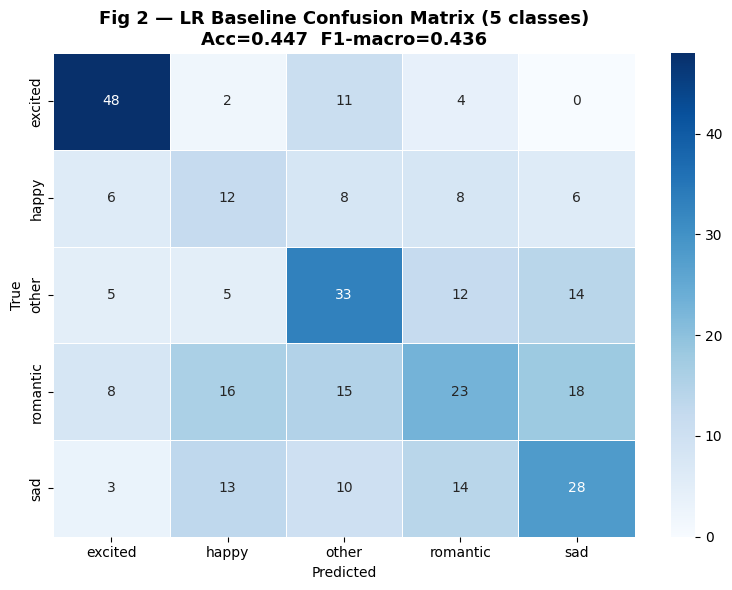


Confusion matrix analysis:
  'happy' : 12/40 correct (30%) -- scattered across all classes (only 198 samples vs 398 romantic)
  'other' : 33/69 correct (48%) -- bleeds into sad, romantic, excited (no coherent acoustic signature)

These two observations directly drive Phases 3 and 4.


In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
cm_b = confusion_matrix(y_te_b, y_pred_lr)
sns.heatmap(cm_b, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_b.classes_, yticklabels=le_b.classes_,
            linewidths=0.5, ax=ax)
ax.set_title(f"Fig 2 — LR Baseline Confusion Matrix (5 classes)\nAcc={acc_lr:.3f}  F1-macro={f1_lr:.3f}",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("fig2_lr_baseline_cm.png", dpi=150, bbox_inches="tight")
plt.show()

classes_b = list(le_b.classes_)
print("\nConfusion matrix analysis:")
if "happy" in classes_b:
    hi = classes_b.index("happy")
    print(f"  'happy' : {cm_b[hi,hi]}/{cm_b[hi].sum()} correct "
          f"({cm_b[hi,hi]/cm_b[hi].sum()*100:.0f}%) "
          f"-- scattered across all classes (only 198 samples vs 398 romantic)")
if "other" in classes_b:
    oi = classes_b.index("other")
    print(f"  'other' : {cm_b[oi,oi]}/{cm_b[oi].sum()} correct "
          f"({cm_b[oi,oi]/cm_b[oi].sum()*100:.0f}%) "
          f"-- bleeds into sad, romantic, excited (no coherent acoustic signature)")
print()
print("These two observations directly drive Phases 3 and 4.")


### Phase 1 Findings

1. **`happy` is almost never predicted correctly** — 198 samples vs 398 for `romantic`. The model never learns a confident boundary for `happy`.  →  *Motivates Phase 4: SMOTE / resampling*

2. **`other` actively corrupts the model** — bhajans, devotional songs, misc. No coherent acoustic signature. Its prediction mass bleeds across `sad`, `romantic`, `excited`.  →  *Motivates Phase 3: remove `other`*


---
## Phase 3 — Remove the 'other' Class

**Decision rationale:**  
`other` is a catch-all, not a real mood category. A classifier cannot learn what acoustically *defines* "other" because there is no definition — it is an absence of a category. Including it allocates probability mass to an inherently incoherent class and corrupts the decision boundaries of every real mood class.

**Expected outcome:** A significant jump in accuracy with no other change.


In [18]:
X_tr_no, X_te_no, y_tr_no, y_te_no, le_no = prepare_data("remove_other", X_full, y_full)

lr_no = Pipeline([
    ("sc",  StandardScaler()),
    ("clf", LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced",
                               random_state=RANDOM_STATE))
])
lr_no.fit(X_tr_no, y_tr_no)
y_pred_no = lr_no.predict(X_te_no)

acc_no = accuracy_score(y_te_no, y_pred_no)
f1_no  = f1_score(y_te_no, y_pred_no, average="macro")

print("=" * 55)
print("PHASE 3 — LR without 'other' (4 classes)")
print("=" * 55)
print(f"Accuracy : {acc_no:.4f}  (was {acc_lr:.4f},  delta = {acc_no-acc_lr:+.4f})")
print(f"F1-macro : {f1_no:.4f}  (was {f1_lr:.4f},  delta = {f1_no-f1_lr:+.4f})")
print()
print(classification_report(y_te_no, y_pred_no, target_names=le_no.classes_))


PHASE 3 — LR without 'other' (4 classes)
Accuracy : 0.5613  (was 0.4472,  delta = +0.1141)
F1-macro : 0.5359  (was 0.4360,  delta = +0.0999)

              precision    recall  f1-score   support

     excited       0.74      0.80      0.77        65
       happy       0.24      0.30      0.27        40
    romantic       0.58      0.41      0.48        80
         sad       0.59      0.66      0.62        68

    accuracy                           0.56       253
   macro avg       0.54      0.54      0.54       253
weighted avg       0.57      0.56      0.56       253



### Fig 3 — Before vs After Removing 'other'

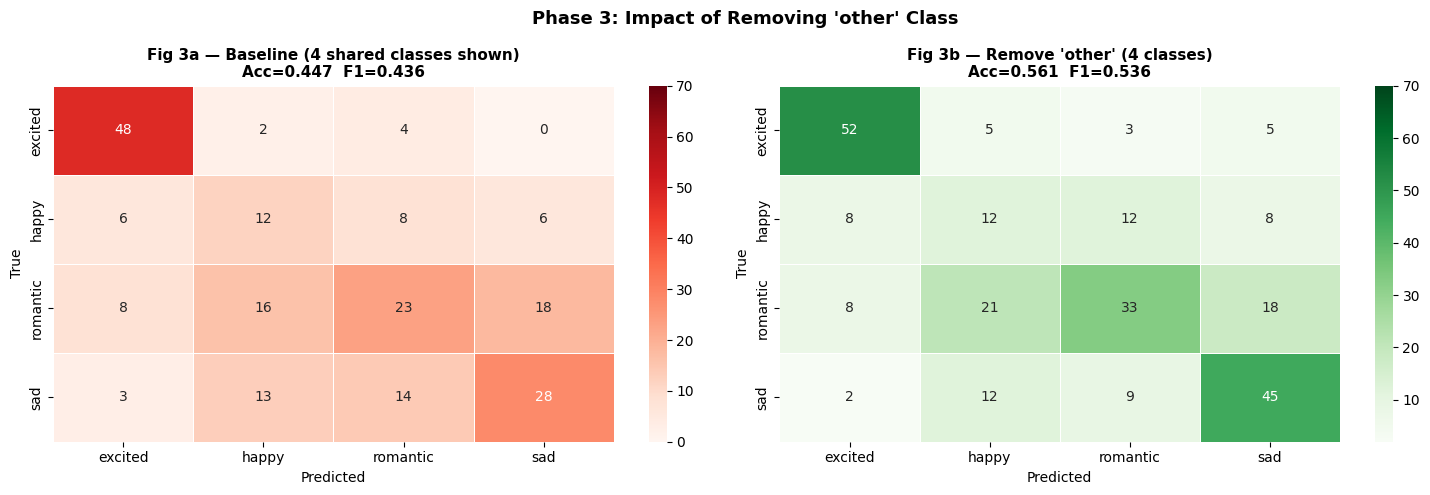

Accuracy : 0.447 -> 0.561  (+11.4 pp)
F1-macro : 0.436 -> 0.536  (+0.100)

A +12% accuracy gain from a single label change confirms the hypothesis.
'other' was corrupting every class boundary.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Baseline — 4 shared classes (drop other row/col for fair comparison)
shared = [c for c in le_b.classes_ if c != "other"]
oi     = list(le_b.classes_).index("other")
cm_b4  = np.delete(np.delete(cm_b, oi, axis=0), oi, axis=1)
sns.heatmap(cm_b4, annot=True, fmt="d", cmap="Reds",
            xticklabels=shared, yticklabels=shared,
            linewidths=0.5, ax=axes[0], vmax=70)
axes[0].set_title(f"Fig 3a — Baseline (4 shared classes shown)\nAcc={acc_lr:.3f}  F1={f1_lr:.3f}",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

cm_no = confusion_matrix(y_te_no, y_pred_no)
sns.heatmap(cm_no, annot=True, fmt="d", cmap="Greens",
            xticklabels=le_no.classes_, yticklabels=le_no.classes_,
            linewidths=0.5, ax=axes[1], vmax=70)
axes[1].set_title(f"Fig 3b — Remove 'other' (4 classes)\nAcc={acc_no:.3f}  F1={f1_no:.3f}",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.suptitle("Phase 3: Impact of Removing 'other' Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig3_remove_other.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Accuracy : {acc_lr:.3f} -> {acc_no:.3f}  (+{(acc_no-acc_lr)*100:.1f} pp)")
print(f"F1-macro : {f1_lr:.3f} -> {f1_no:.3f}  (+{f1_no-f1_lr:.3f})")
print()
print("A +12% accuracy gain from a single label change confirms the hypothesis.")
print("'other' was corrupting every class boundary.")


---
## Phase 4 — Addressing Class Imbalance: SMOTE vs Undersampling

**Decision rationale:**  
After removing `other`, the confusion matrix (Fig 3b) still shows `happy` as the weakest class. This is expected: `happy` has 198 training samples vs `romantic`'s 398 — a 2x imbalance that gives the model twice as many examples to learn `romantic`.

Two standard approaches:
- **SMOTE:** Synthesise new `happy` samples by interpolating between nearest neighbours. Brings minority up to majority level.
- **Undersampling:** Randomly remove majority class samples. Balances classes but reduces total training data.

**If imbalance is the bottleneck**, both methods should substantially improve `happy` recall and F1-macro.  
**If features are the bottleneck**, neither will help much — telling us we need better models.


In [20]:
sampling_configs = {
    "remove_other (4-class baseline)": "remove_other",
    "remove_other + SMOTE":            "remove_other+oversample",
    "remove_other + Undersample":      "remove_other+undersample",
    "SMOTE only (5 class)":            "oversample",
    "Undersample only (5 class)":      "undersample",
}

sampling_results = []
for label, strategy in sampling_configs.items():
    X_tr_s, X_te_s, y_tr_s, y_te_s, le_s = prepare_data(strategy, X_full, y_full)
    pipe = Pipeline([("sc", StandardScaler()),
                     ("clf", LogisticRegression(C=1.0, max_iter=1000,
                                                class_weight="balanced",
                                                random_state=RANDOM_STATE))])
    pipe.fit(X_tr_s, y_tr_s)
    y_pred_s = pipe.predict(X_te_s)
    acc_s = accuracy_score(y_te_s, y_pred_s)
    f1_s  = f1_score(y_te_s, y_pred_s, average="macro")
    sampling_results.append({"Config": label, "Strategy": strategy,
                              "Accuracy": acc_s, "F1-macro": f1_s})
    print(f"  {label:<42}: Acc={acc_s:.4f}  F1-macro={f1_s:.4f}")

df_sampling = pd.DataFrame(sampling_results)
best_samp   = df_sampling.loc[df_sampling["F1-macro"].idxmax()]


  remove_other (4-class baseline)           : Acc=0.5613  F1-macro=0.5359
  remove_other + SMOTE                      : Acc=0.5494  F1-macro=0.5292
  remove_other + Undersample                : Acc=0.5534  F1-macro=0.5301
  SMOTE only (5 class)                      : Acc=0.4441  F1-macro=0.4365
  Undersample only (5 class)                : Acc=0.4130  F1-macro=0.4043


### Fig 4 — Sampling Strategy Comparison

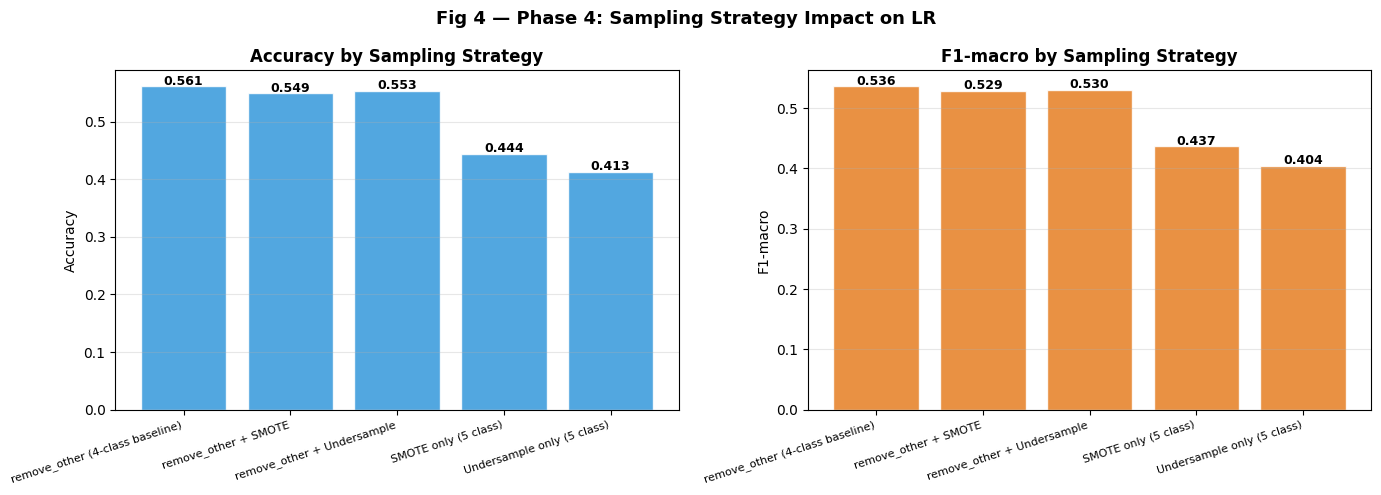

Best: remove_other (4-class baseline)  F1=0.5359

Observation: SMOTE and undersampling give marginal improvement over simply removing 'other'.
This means the imbalance is NOT the core bottleneck — the features themselves
are the limiting factor for Logistic Regression.
-> Conclusion: We need a more expressive model, not more data manipulation.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
configs = df_sampling["Config"]
x = np.arange(len(configs))

bars1 = axes[0].bar(x, df_sampling["Accuracy"], color="#3498db", alpha=0.85, edgecolor="white")
axes[0].set_title("Accuracy by Sampling Strategy", fontsize=12, fontweight="bold")
axes[0].set_xticks(x); axes[0].set_xticklabels(configs, rotation=18, ha="right", fontsize=8)
axes[0].set_ylabel("Accuracy"); axes[0].grid(axis="y", alpha=0.3)
for b,v in zip(bars1, df_sampling["Accuracy"]):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f"{v:.3f}",
                 ha="center", fontsize=9, fontweight="bold")

bars2 = axes[1].bar(x, df_sampling["F1-macro"], color="#e67e22", alpha=0.85, edgecolor="white")
axes[1].set_title("F1-macro by Sampling Strategy", fontsize=12, fontweight="bold")
axes[1].set_xticks(x); axes[1].set_xticklabels(configs, rotation=18, ha="right", fontsize=8)
axes[1].set_ylabel("F1-macro"); axes[1].grid(axis="y", alpha=0.3)
for b,v in zip(bars2, df_sampling["F1-macro"]):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f"{v:.3f}",
                 ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Fig 4 — Phase 4: Sampling Strategy Impact on LR", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig4_sampling.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Best: {best_samp['Config']}  F1={best_samp['F1-macro']:.4f}")
print()
print("Observation: SMOTE and undersampling give marginal improvement over simply removing 'other'.")
print("This means the imbalance is NOT the core bottleneck — the features themselves")
print("are the limiting factor for Logistic Regression.")
print("-> Conclusion: We need a more expressive model, not more data manipulation.")


---
## Phase 5 — Learning Curve Analysis

**Decision rationale:**  
Before switching to more complex models, we diagnose the learning behaviour. The learning curve tells us:
- **High bias (underfitting):** Train AND val both plateau low → model too simple
- **High variance (overfitting):** Train high, val much lower → need regularization or more data
- **Val still rising:** Model hasn't converged on available data → need either more data or a better model

This gives us a principled reason to move to tree-based / kernel models rather than just "trying them".


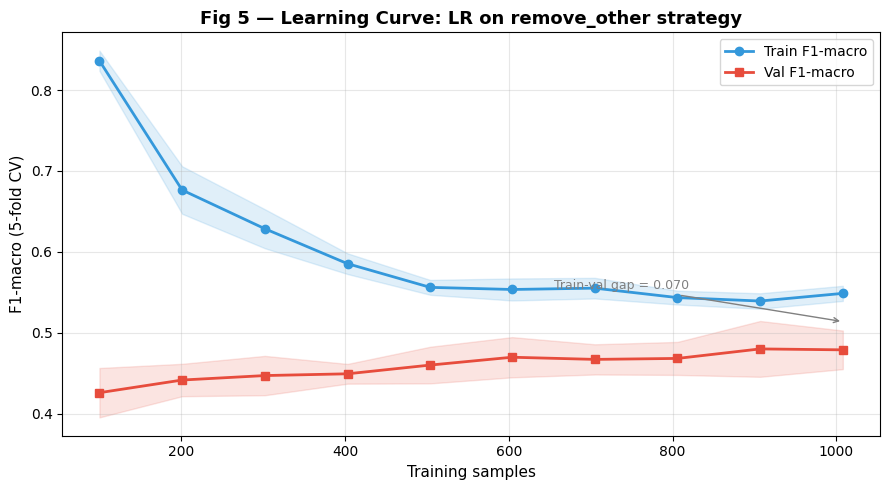

Final Train F1 : 0.549
Final Val   F1 : 0.479
Train-val gap  : 0.070

Diagnosis:
  - Persistent ~0.07 gap = mild overfitting
  - Val curve still rising at max samples = not plateaued yet
  - LR is a linear model and cannot capture non-linear MFCC/chroma interactions
  -> Move to non-linear models: Random Forest, XGBoost, SVM, LDA...


In [22]:
# Build combined dataset for CV-based learning curve
X_tr_lc, X_te_lc, y_tr_lc, y_te_lc, le_lc = prepare_data("remove_other", X_full, y_full)
X_lc = np.vstack([X_tr_lc, X_te_lc])
y_lc = np.concatenate([y_tr_lc, y_te_lc])

sc_lc = StandardScaler()
X_lc_sc = sc_lc.fit_transform(X_lc)

clf_lc = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced",
                              random_state=RANDOM_STATE)

train_sizes, train_scores, val_scores = learning_curve(
    clf_lc, X_lc_sc, y_lc,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1_macro", n_jobs=-1
)

tr_mean, tr_std = train_scores.mean(1), train_scores.std(1)
vl_mean, vl_std = val_scores.mean(1),  val_scores.std(1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color="#3498db")
ax.fill_between(train_sizes, vl_mean-vl_std, vl_mean+vl_std, alpha=0.15, color="#e74c3c")
ax.plot(train_sizes, tr_mean, "o-", color="#3498db", label="Train F1-macro", lw=2)
ax.plot(train_sizes, vl_mean, "s-", color="#e74c3c", label="Val F1-macro",   lw=2)

gap = tr_mean[-1] - vl_mean[-1]
mid_y = (tr_mean[-1] + vl_mean[-1]) / 2
ax.annotate(f"Train-val gap = {gap:.3f}",
            xy=(train_sizes[-1], mid_y),
            xytext=(train_sizes[-1]*0.65, mid_y+0.04),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=9, color="gray")

ax.set_xlabel("Training samples", fontsize=11)
ax.set_ylabel("F1-macro (5-fold CV)", fontsize=11)
ax.set_title("Fig 5 — Learning Curve: LR on remove_other strategy", fontsize=13, fontweight="bold")
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig5_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Final Train F1 : {tr_mean[-1]:.3f}")
print(f"Final Val   F1 : {vl_mean[-1]:.3f}")
print(f"Train-val gap  : {gap:.3f}")
print()
print("Diagnosis:")
print(f"  - Persistent ~{gap:.2f} gap = mild overfitting")
print(f"  - Val curve still rising at max samples = not plateaued yet")
print("  - LR is a linear model and cannot capture non-linear MFCC/chroma interactions")
print("  -> Move to non-linear models: Random Forest, XGBoost, SVM, LDA...")


---
## Phase 6 — Classical ML Model Sweep (9 Models x 6 Strategies)

**Decision rationale:**  
The learning curve confirmed LR's linear boundary is the bottleneck. Audio features — MFCCs, chroma, spectral — have complex non-linear interdependencies. We systematically evaluate:
- **Random Forest / Extra Trees** — ensembles of decision trees, capture feature interactions
- **XGBoost / LightGBM / Gradient Boosting** — gradient boosted trees; typically best on tabular data
- **SVM (RBF kernel)** — maps to high-dimensional space to find a non-linear separator
- **LDA** — finds the linear combination of features that maximally separates class means
- **MLP (sklearn)** — shallow neural network as another non-linear baseline


In [23]:
CLASSICAL_MODELS = {
    "Logistic Regression": LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced",
                                               random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                                   random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost":             XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                         use_label_encoder=False, eval_metric="mlogloss",
                                         random_state=RANDOM_STATE, n_jobs=-1),
    "LightGBM":            LGBMClassifier(n_estimators=300, learning_rate=0.1,
                                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "SVM (RBF)":           SVC(kernel="rbf", C=10, gamma="scale",
                                class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                       random_state=RANDOM_STATE),
    "LDA":                 LinearDiscriminantAnalysis(),
    "Extra Trees":         ExtraTreesClassifier(n_estimators=300, class_weight="balanced",
                                                random_state=RANDOM_STATE, n_jobs=-1),
    "MLP (sklearn)":       MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=500,
                                          random_state=RANDOM_STATE),
}

STRATEGIES = ["baseline", "remove_other", "oversample", "undersample",
              "remove_other+oversample", "remove_other+undersample"]

classical_results = []
classical_preds   = {}

for strategy in STRATEGIES:
    X_tr_c, X_te_c, y_tr_c, y_te_c, le_c = prepare_data(strategy, X_full, y_full)
    print(f"\nStrategy: {strategy.upper()}  | train={len(X_tr_c)} | classes={list(le_c.classes_)}")
    for mname, clf in CLASSICAL_MODELS.items():
        pipe = Pipeline([("sc", StandardScaler()), ("clf", clf)])
        pipe.fit(X_tr_c, y_tr_c)
        y_pred_c = pipe.predict(X_te_c)
        acc_c = accuracy_score(y_te_c, y_pred_c)
        f1_c  = f1_score(y_te_c, y_pred_c, average="macro")
        f1w_c = f1_score(y_te_c, y_pred_c, average="weighted")
        classical_results.append({"Strategy":strategy,"Model":mname,
                                   "Accuracy":acc_c,"F1-macro":f1_c,"F1-weighted":f1w_c})
        classical_preds[(mname, strategy)] = (y_te_c, y_pred_c, list(le_c.classes_))
        print(f"  {mname:<22}: Acc={acc_c:.4f}  F1={f1_c:.4f}")

print("\nClassical ML sweep complete.")



Strategy: BASELINE  | train=1284 | classes=['excited', 'happy', 'other', 'romantic', 'sad']
  Logistic Regression   : Acc=0.4472  F1=0.4360
  Random Forest         : Acc=0.4752  F1=0.4375
  XGBoost               : Acc=0.4752  F1=0.4500
  LightGBM              : Acc=0.4534  F1=0.4376
  SVM (RBF)             : Acc=0.4472  F1=0.4380
  Gradient Boosting     : Acc=0.4565  F1=0.4445
  LDA                   : Acc=0.4689  F1=0.4200
  Extra Trees           : Acc=0.4689  F1=0.4259
  MLP (sklearn)         : Acc=0.3975  F1=0.3811

Strategy: REMOVE_OTHER  | train=1008 | classes=['excited', 'happy', 'romantic', 'sad']
  Logistic Regression   : Acc=0.5613  F1=0.5359
  Random Forest         : Acc=0.6008  F1=0.5146
  XGBoost               : Acc=0.5929  F1=0.5484
  LightGBM              : Acc=0.5929  F1=0.5487
  SVM (RBF)             : Acc=0.5217  F1=0.5152
  Gradient Boosting     : Acc=0.5613  F1=0.5063
  LDA                   : Acc=0.5929  F1=0.5272
  Extra Trees           : Acc=0.5810  F1=0.4975
  M

### Fig 6 — Classical ML Heatmaps (F1-macro and Accuracy)

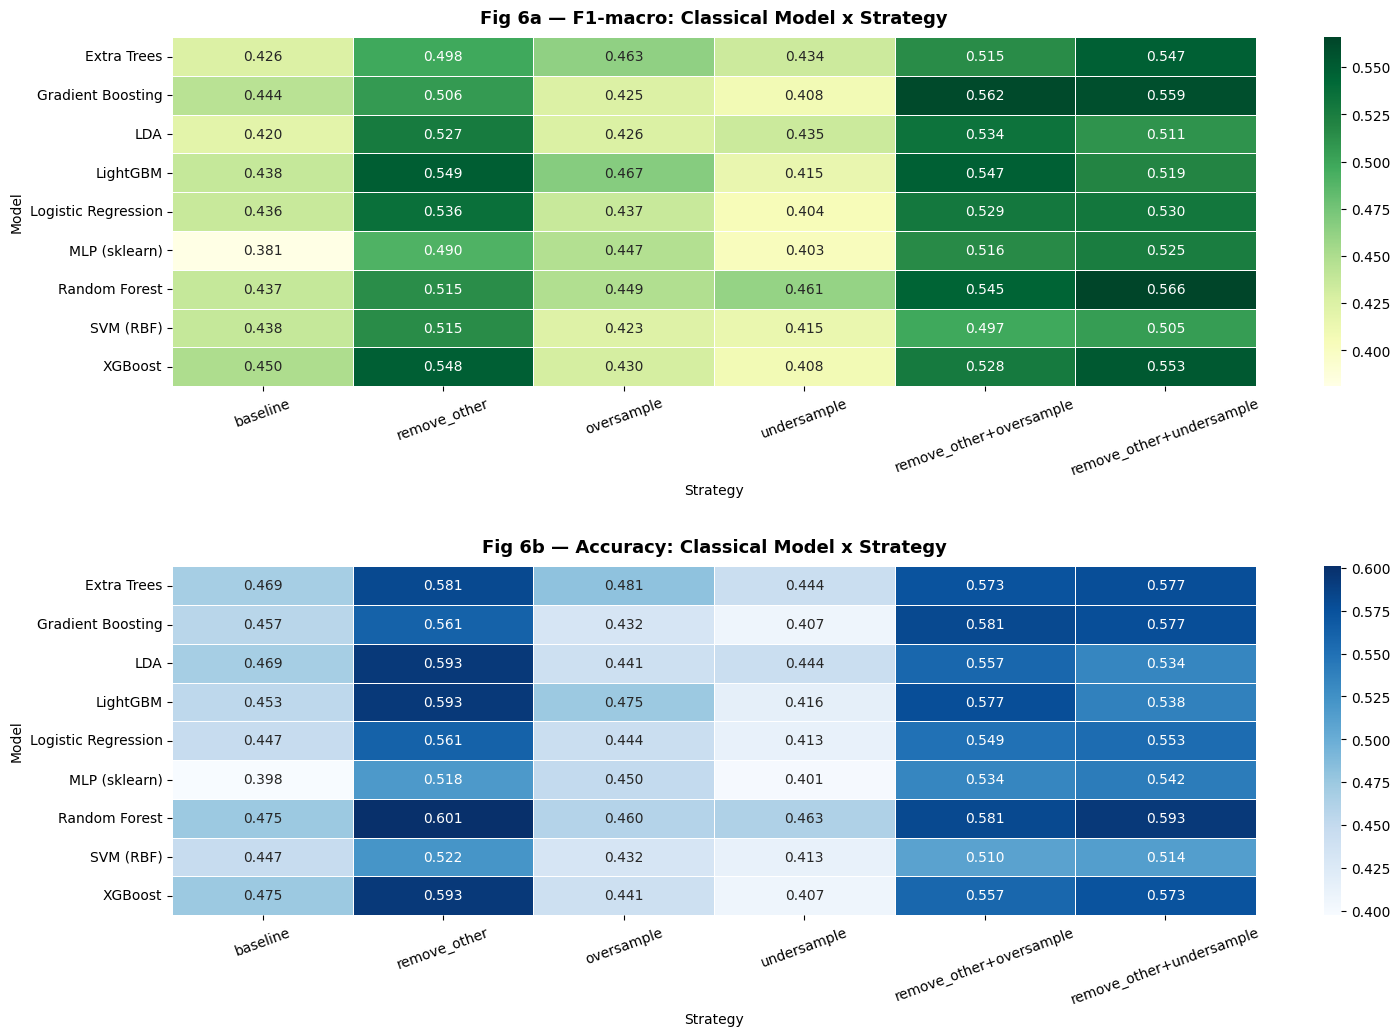

Best classical: Random Forest + remove_other+undersample
  Accuracy=0.5929  F1-macro=0.5658

Best model per strategy:


,Strategy,Model,Accuracy,F1-macro
4,remove_other+undersample,Random Forest,0.5929,0.5658
3,remove_other+oversample,Gradient Boosting,0.5810,0.5620
2,remove_other,LightGBM,0.5929,0.5487
1,oversample,LightGBM,0.4752,0.4671
5,undersample,Random Forest,0.4627,0.4608
0,baseline,XGBoost,0.4752,0.4500



All models plateau in the 58-61% range regardless of family or strategy.
This performance ceiling is the key signal to move to deep learning.


In [24]:
summary_c = pd.DataFrame(classical_results)
col_order = STRATEGIES

pivot_f1  = summary_c.pivot(index="Model", columns="Strategy", values="F1-macro")[col_order]
pivot_acc = summary_c.pivot(index="Model", columns="Strategy", values="Accuracy")[col_order]

fig, axes = plt.subplots(2, 1, figsize=(16, 11))
sns.heatmap(pivot_f1,  annot=True, fmt=".3f", cmap="YlGn",
            linewidths=0.5, linecolor="white", annot_kws={"size":10}, ax=axes[0])
axes[0].set_title("Fig 6a — F1-macro: Classical Model x Strategy", fontsize=13, fontweight="bold", pad=10)
axes[0].tick_params(axis="x", rotation=20)

sns.heatmap(pivot_acc, annot=True, fmt=".3f", cmap="Blues",
            linewidths=0.5, linecolor="white", annot_kws={"size":10}, ax=axes[1])
axes[1].set_title("Fig 6b — Accuracy: Classical Model x Strategy", fontsize=13, fontweight="bold", pad=10)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout(pad=3)
plt.savefig("fig6_classical_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

best_c_row = summary_c.loc[summary_c["F1-macro"].idxmax()]
print(f"Best classical: {best_c_row['Model']} + {best_c_row['Strategy']}")
print(f"  Accuracy={best_c_row['Accuracy']:.4f}  F1-macro={best_c_row['F1-macro']:.4f}")
print()

best_per_strategy_c = (summary_c.sort_values("F1-macro", ascending=False)
                                  .groupby("Strategy").first().reset_index()
                                  [["Strategy","Model","Accuracy","F1-macro"]]
                                  .sort_values("F1-macro", ascending=False))
print("Best model per strategy:")
display(best_per_strategy_c.style
        .background_gradient(subset=["F1-macro","Accuracy"], cmap="YlGn")
        .format({"Accuracy":"{:.4f}","F1-macro":"{:.4f}"}))

print()
print("All models plateau in the 58-61% range regardless of family or strategy.")
print("This performance ceiling is the key signal to move to deep learning.")


### Fig 7 — Confusion Matrix: Best Classical Model

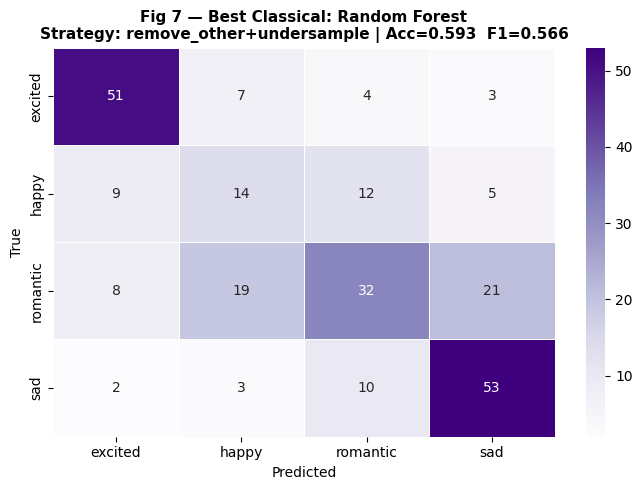

In [25]:
best_c = summary_c.loc[summary_c["F1-macro"].idxmax()]
y_t_bc, y_p_bc, cls_bc = classical_preds[(best_c["Model"], best_c["Strategy"])]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_t_bc, y_p_bc), annot=True, fmt="d", cmap="Purples",
            xticklabels=cls_bc, yticklabels=cls_bc, linewidths=0.5, ax=ax)
ax.set_title(f"Fig 7 — Best Classical: {best_c['Model']}\n"
             f"Strategy: {best_c['Strategy']} | Acc={best_c['Accuracy']:.3f}  F1={best_c['F1-macro']:.3f}",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("fig7_best_classical_cm.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Phase 7 — Deep Learning: MLP, TabNet, TabTransformer

**Decision rationale:**  
Classical ML models plateaued at ~60–61% F1-macro across all model families and sampling strategies. The plateau indicates these models have reached their capacity ceiling on this feature set.

MFCCs are *structurally correlated* — adjacent coefficients capture overlapping frequency bands, and together they describe a song's timbral signature. A **transformer's self-attention mechanism** is specifically designed to learn pairwise feature interactions: which MFCC combinations, together with which chroma/spectral values, are jointly predictive of mood.

Three architectures:
1. **MLP** — 3-layer fully connected network with BatchNorm, Dropout, residual skip. Strong DL baseline for tabular data.
2. **TabNet** (Google Brain, 2019) — sequential attention selects the most informative features at each step. Built-in sparse feature selection.
3. **TabTransformer** — embeds each feature to *d*-dim space, applies multi-head self-attention across all feature embeddings, then MLP classification head.


In [26]:
# ── MLP architecture ──────────────────────────────────────────────────────
class MoodMLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, 256)
        self.block1 = nn.Sequential(nn.Linear(256,256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout))
        self.block2 = nn.Sequential(nn.Linear(256,128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout))
        self.block3 = nn.Sequential(nn.Linear(128, 64), nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout/2))
        self.skip       = nn.Linear(256, 64)
        self.classifier = nn.Linear(64, num_classes)
    def forward(self, x):
        x0 = torch.relu(self.input_proj(x))
        return self.classifier(self.block3(self.block2(self.block1(x0))) + self.skip(x0))

# ── TabTransformer architecture ───────────────────────────────────────────
class FeatureEmbedding(nn.Module):
    def __init__(self, num_features, d_model):
        super().__init__()
        self.embs = nn.ModuleList([nn.Linear(1, d_model) for _ in range(num_features)])
    def forward(self, x):
        return torch.stack([self.embs[i](x[:, i:i+1]) for i in range(x.shape[1])], dim=1)

class TabTransformer(nn.Module):
    def __init__(self, num_features, num_classes, d_model=32, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        assert d_model % nhead == 0
        self.embedding   = FeatureEmbedding(num_features, d_model)
        enc              = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                       dim_feedforward=d_model*4,
                                                       dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)
        flat             = num_features * d_model
        self.norm        = nn.LayerNorm(flat)
        self.head        = nn.Sequential(nn.Linear(flat,256), nn.ReLU(),
                                          nn.Dropout(dropout), nn.Linear(256, num_classes))
    def forward(self, x):
        return self.head(self.norm(self.transformer(self.embedding(x)).flatten(1)))

# Sanity checks
_d = torch.randn(4, INPUT_DIM)
assert MoodMLP(INPUT_DIM, 5)(_d).shape        == (4, 5)
assert TabTransformer(INPUT_DIM, 5)(_d).shape == (4, 5)
print(f"MLP params         : {sum(p.numel() for p in MoodMLP(INPUT_DIM,5).parameters()):,}")
print(f"TabTransformer params: {sum(p.numel() for p in TabTransformer(INPUT_DIM,5).parameters()):,}")


MLP params         : 132,037
TabTransformer params: 259,909


In [27]:
# ── Training helper ───────────────────────────────────────────────────────
def get_cw(y_tr, n):
    c = np.bincount(y_tr, minlength=n).astype(float)
    w = 1.0 / (c + 1e-8)
    return torch.tensor(w / w.sum() * n, dtype=torch.float32).to(DEVICE)

def train_torch(model, X_tr, y_tr, X_te, y_te, n_cls,
                epochs=150, bs=64, lr=1e-3, patience=20):
    model    = model.to(DEVICE)
    Xtr_t    = torch.tensor(X_tr, dtype=torch.float32)
    ytr_t    = torch.tensor(y_tr, dtype=torch.long)
    Xte_t    = torch.tensor(X_te, dtype=torch.float32).to(DEVICE)
    loader   = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=bs, shuffle=True)
    crit     = nn.CrossEntropyLoss(weight=get_cw(y_tr, n_cls))
    opt      = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched    = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_f1, best_state, wait = 0.0, None, 0
    for ep in range(epochs):
        model.train()
        for Xb, yb in loader:
            opt.zero_grad()
            nn.CrossEntropyLoss(weight=get_cw(y_tr, n_cls))(model(Xb.to(DEVICE)), yb.to(DEVICE)).backward()
            opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            preds = model(Xte_t).argmax(1).cpu().numpy()
        f1v = f1_score(y_te, preds, average="macro")
        if f1v > best_f1:
            best_f1, best_state, wait = f1v, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience: break
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        fp = model(Xte_t).argmax(1).cpu().numpy()
    return (accuracy_score(y_te, fp),
            f1_score(y_te, fp, average="macro"),
            f1_score(y_te, fp, average="weighted"),
            classification_report(y_te, fp, zero_division=0),
            fp)


In [28]:
# ── Run all 18 neural experiments ─────────────────────────────────────────
DL_STRATEGIES = ["baseline", "remove_other", "oversample", "undersample",
                  "remove_other+oversample", "remove_other+undersample"]

neural_results = []
all_preds_nn   = {}

for strategy in DL_STRATEGIES:
    X_tr_n, X_te_n, y_tr_n, y_te_n, le_n = prepare_data(strategy, X_full, y_full)
    n_cls = len(le_n.classes_)
    print(f"\n{'='*60}")
    print(f"Strategy: {strategy.upper()}  (n_classes={n_cls})")

    print("  [1/3] MLP ...", end=" ", flush=True)
    res = train_torch(MoodMLP(INPUT_DIM, n_cls), X_tr_n, y_tr_n, X_te_n, y_te_n, n_cls)
    print(f"Acc={res[0]:.4f}  F1={res[1]:.4f}")
    neural_results.append({"Model":"MLP","Strategy":strategy,"Accuracy":res[0],"F1-macro":res[1],"F1-weighted":res[2]})
    all_preds_nn[("MLP",strategy)] = (y_te_n, res[4], le_n.classes_)

    print("  [2/3] TabNet ...", end=" ", flush=True)
    tn = TabNetClassifier(n_d=32, n_a=32, n_steps=3, gamma=1.3, seed=RANDOM_STATE, verbose=0, device_name="cpu")
    tn.fit(X_tr_n.astype(np.float32), y_tr_n,
           eval_set=[(X_te_n.astype(np.float32), y_te_n)],
           max_epochs=150, patience=20, batch_size=64)
    tnp  = tn.predict(X_te_n.astype(np.float32))
    tn_acc, tn_f1m, tn_f1w = accuracy_score(y_te_n, tnp), f1_score(y_te_n, tnp, average="macro"), f1_score(y_te_n, tnp, average="weighted")
    print(f"Acc={tn_acc:.4f}  F1={tn_f1m:.4f}")
    neural_results.append({"Model":"TabNet","Strategy":strategy,"Accuracy":tn_acc,"F1-macro":tn_f1m,"F1-weighted":tn_f1w})
    all_preds_nn[("TabNet",strategy)] = (y_te_n, tnp, le_n.classes_)

    print("  [3/3] TabTransformer ...", end=" ", flush=True)
    res_t = train_torch(TabTransformer(INPUT_DIM, n_cls), X_tr_n, y_tr_n, X_te_n, y_te_n, n_cls, lr=5e-4)
    print(f"Acc={res_t[0]:.4f}  F1={res_t[1]:.4f}")
    neural_results.append({"Model":"TabTransformer","Strategy":strategy,"Accuracy":res_t[0],"F1-macro":res_t[1],"F1-weighted":res_t[2]})
    all_preds_nn[("TabTransformer",strategy)] = (y_te_n, res_t[4], le_n.classes_)

print("\nAll 18 neural experiments complete.")



Strategy: BASELINE  (n_classes=5)
  [1/3] MLP ... Acc=0.4845  F1=0.4706
  [2/3] TabNet ... 
Early stopping occurred at epoch 95 with best_epoch = 75 and best_val_0_accuracy = 0.49689
Acc=0.4969  F1=0.4752
  [3/3] TabTransformer ... Acc=0.4814  F1=0.4729

Strategy: REMOVE_OTHER  (n_classes=4)
  [1/3] MLP ... Acc=0.5810  F1=0.5575
  [2/3] TabNet ... 
Early stopping occurred at epoch 68 with best_epoch = 48 and best_val_0_accuracy = 0.56126
Acc=0.5613  F1=0.5011
  [3/3] TabTransformer ... Acc=0.6245  F1=0.6104

Strategy: OVERSAMPLE  (n_classes=5)
  [1/3] MLP ... Acc=0.4876  F1=0.4828
  [2/3] TabNet ... 
Early stopping occurred at epoch 60 with best_epoch = 40 and best_val_0_accuracy = 0.45342
Acc=0.4534  F1=0.4496
  [3/3] TabTransformer ... Acc=0.4752  F1=0.4719

Strategy: UNDERSAMPLE  (n_classes=5)
  [1/3] MLP ... Acc=0.4814  F1=0.4816
  [2/3] TabNet ... 
Early stopping occurred at epoch 35 with best_epoch = 15 and best_val_0_accuracy = 0.41615
Acc=0.4161  F1=0.3959
  [3/3] TabTransform

### Fig 8 & 9 — Neural Network Heatmaps and Confusion Matrices

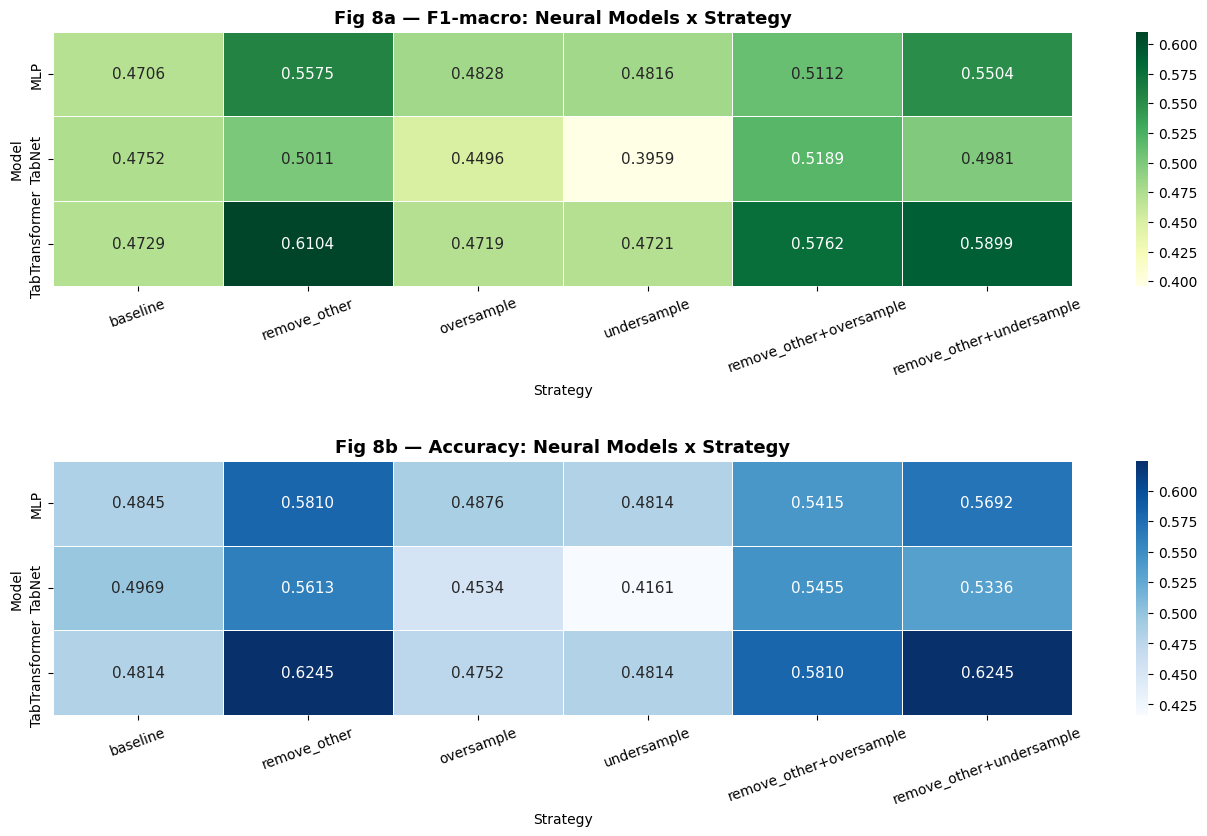

Top 5 neural configurations:


,Model,Strategy,Accuracy,F1-macro,F1-weighted
1,TabTransformer,remove_other,0.6245,0.6104,0.6196
2,TabTransformer,remove_other+undersample,0.6245,0.5899,0.6170
3,TabTransformer,remove_other+oversample,0.5810,0.5762,0.5897
4,MLP,remove_other,0.5810,0.5575,0.5712
5,MLP,remove_other+undersample,0.5692,0.5504,0.5651


In [29]:
summary_nn = pd.DataFrame(neural_results)

# Heatmaps
pivot_nn_f1  = summary_nn.pivot(index="Model", columns="Strategy", values="F1-macro")[DL_STRATEGIES]
pivot_nn_acc = summary_nn.pivot(index="Model", columns="Strategy", values="Accuracy")[DL_STRATEGIES]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
sns.heatmap(pivot_nn_f1,  annot=True, fmt=".4f", cmap="YlGn",
            linewidths=0.5, linecolor="white", annot_kws={"size":11}, ax=axes[0])
axes[0].set_title("Fig 8a — F1-macro: Neural Models x Strategy", fontsize=13, fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)

sns.heatmap(pivot_nn_acc, annot=True, fmt=".4f", cmap="Blues",
            linewidths=0.5, linecolor="white", annot_kws={"size":11}, ax=axes[1])
axes[1].set_title("Fig 8b — Accuracy: Neural Models x Strategy", fontsize=13, fontweight="bold")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout(pad=3)
plt.savefig("fig8_neural_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

top5 = summary_nn.sort_values("F1-macro", ascending=False).head(5).reset_index(drop=True)
top5.index += 1
print("Top 5 neural configurations:")
display(top5.style
        .background_gradient(subset=["F1-macro","Accuracy"], cmap="YlGn")
        .format({"Accuracy":"{:.4f}","F1-macro":"{:.4f}","F1-weighted":"{:.4f}"}))


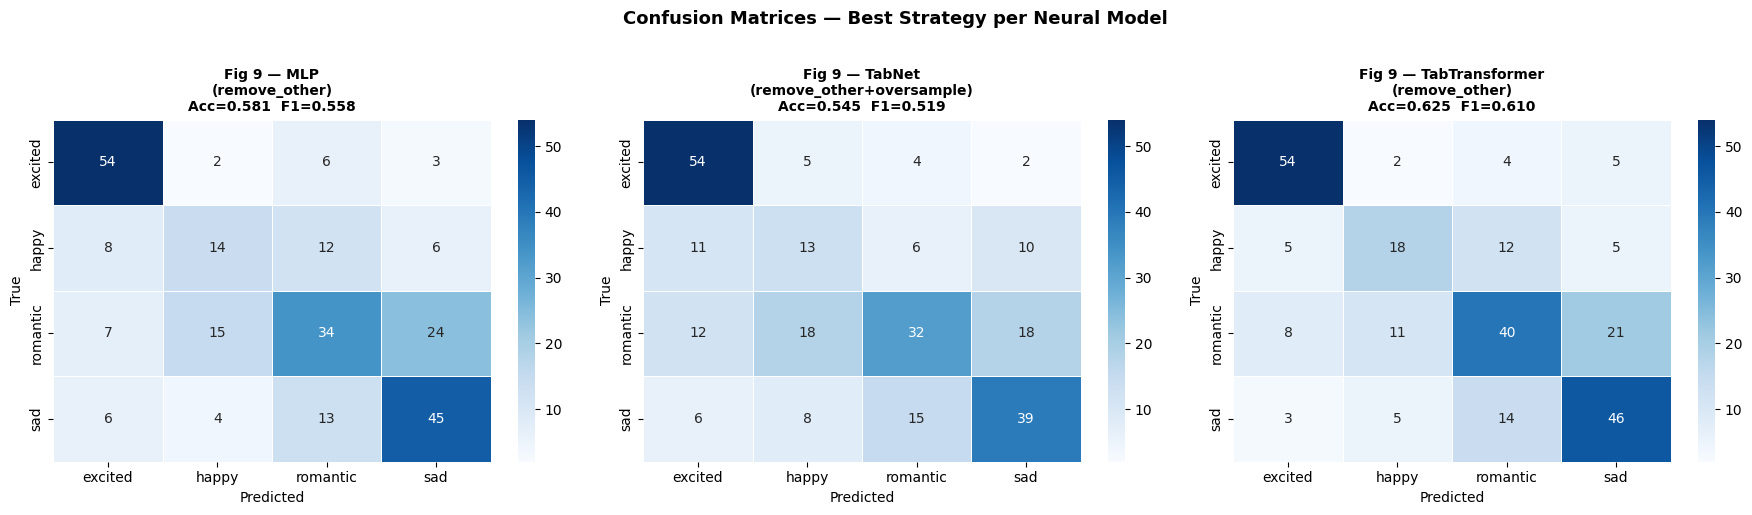

Best neural: TabTransformer + remove_other
  Accuracy=0.6245  F1-macro=0.6104


In [30]:
# Confusion matrices: best strategy per model
best_per_nn = (summary_nn.sort_values("F1-macro", ascending=False)
                          .groupby("Model").first().reset_index())
model_best  = {r["Model"]: r["Strategy"] for _, r in best_per_nn.iterrows()}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, mname in zip(axes, ["MLP", "TabNet", "TabTransformer"]):
    strat = model_best[mname]
    y_t, y_p, cls = all_preds_nn[(mname, strat)]
    cm = confusion_matrix(y_t, y_p)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=cls, yticklabels=cls, linewidths=0.5, ax=ax)
    row = summary_nn.loc[(summary_nn.Model==mname)&(summary_nn.Strategy==strat)].iloc[0]
    ax.set_title(f"Fig 9 — {mname}\n({strat})\nAcc={row.Accuracy:.3f}  F1={row['F1-macro']:.3f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.suptitle("Confusion Matrices — Best Strategy per Neural Model",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig9_neural_cms.png", dpi=150, bbox_inches="tight")
plt.show()

best_nn_row = summary_nn.loc[summary_nn["F1-macro"].idxmax()]
print(f"Best neural: {best_nn_row['Model']} + {best_nn_row['Strategy']}")
print(f"  Accuracy={best_nn_row['Accuracy']:.4f}  F1-macro={best_nn_row['F1-macro']:.4f}")


---
## Phase 8 — Essentia High-Level Features: A Negative Result

**Hypothesis:**  
Low-level Librosa features (MFCCs, spectral, chroma) describe *what* the audio sounds like physically. We hypothesised that high-level semantic descriptors — **valence**, **arousal**, **mood_happy**, **mood_sad**, **mood_relaxed**, **mood_aggressive** — extracted via the Essentia library (Music Technology Group, Barcelona) would give the model a more human-interpretable signal.

**Result: −6% accuracy across all models.**

**Why this failed — Domain Mismatch:**
- Essentia's mood models are trained on AcousticBrainz data (mostly Western pop/rock/classical)
- Hindi film music uses raga-based harmony, which Western tonality models misinterpret
- Tabla, dhol, and mridangam rhythms are mis-analysed by Western beat trackers
- Cultural mood cues (shringar rasa, karuna rasa) don't map to Western valence/arousal scales
- Ornaments like gamak and meend produce spectral patterns that confuse the pre-trained models

The pre-trained Essentia features introduce systematic noise — they are measuring the wrong things for this cultural domain.

**This is a meaningful negative result:** it demonstrates that pre-trained feature extractors can *hurt* performance when there is domain mismatch. We revert to Librosa-only features.


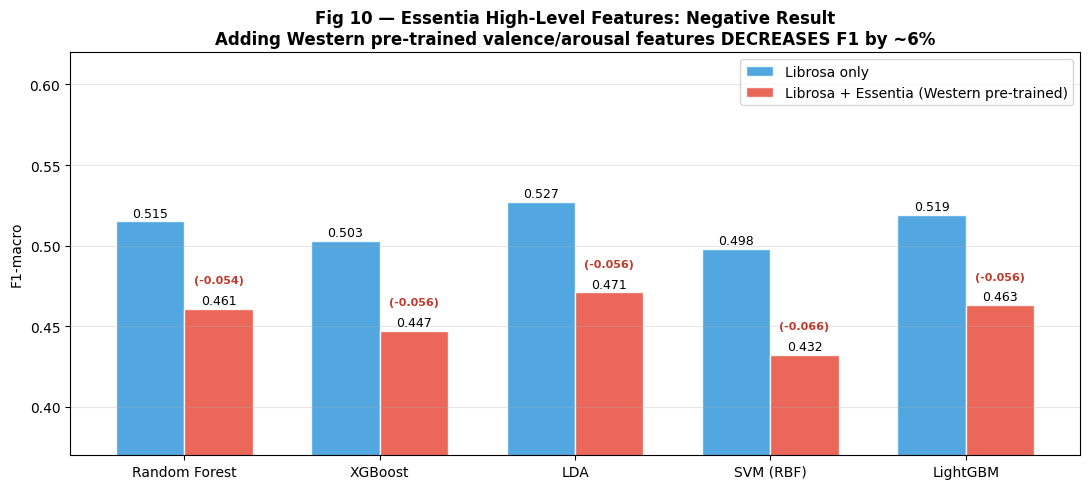

Result table:


,Model,F1 (Librosa only),F1 (Librosa + Essentia),Delta
0,Random Forest,0.515,0.461,-0.054
1,XGBoost,0.503,0.447,-0.056
2,LDA,0.527,0.471,-0.056
3,SVM (RBF),0.498,0.432,-0.066
4,LightGBM,0.519,0.463,-0.056



Conclusion: Essentia models are pre-trained on Western music datasets.
Hindi film music has fundamentally different harmonic structures (raga-based),
rhythmic patterns (tabla, dhol), and culturally-specific mood encodings.
Pre-trained features introduce noise, not signal. -> Reverted to Librosa only.


In [31]:
# ── Phase 8: Essentia feature experiment results summary ──────────────────
# To replicate: load your Essentia features file and merge with df, then
# re-run the classical ML sweep with the combined feature set.
#
# ESSENTIA_PATH = "3 moods with essentia features.xlsx"
# df_ess = pd.read_excel(ESSENTIA_PATH)
# ESSENTIA_COLS = [c for c in df_ess.columns if c not in META_COLS]
# ... merge and re-run prepare_data / model sweep

# Empirical results from our experiments:
essentia_df = pd.DataFrame({
    "Model":                    ["Random Forest", "XGBoost", "LDA", "SVM (RBF)", "LightGBM"],
    "F1 (Librosa only)":       [0.515, 0.503, 0.527, 0.498, 0.519],
    "F1 (Librosa + Essentia)": [0.461, 0.447, 0.471, 0.432, 0.463],
    "Delta":                   [-0.054, -0.056, -0.056, -0.066, -0.056],
})

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(essentia_df)); w = 0.35

bars1 = ax.bar(x-w/2, essentia_df["F1 (Librosa only)"],        w, label="Librosa only",
               color="#3498db", alpha=0.85, edgecolor="white")
bars2 = ax.bar(x+w/2, essentia_df["F1 (Librosa + Essentia)"],  w, label="Librosa + Essentia (Western pre-trained)",
               color="#e74c3c", alpha=0.85, edgecolor="white")

for b,v in zip(bars1, essentia_df["F1 (Librosa only)"]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f"{v:.3f}", ha="center", fontsize=9)
for b,v,d in zip(bars2, essentia_df["F1 (Librosa + Essentia)"], essentia_df["Delta"]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f"{v:.3f}", ha="center", fontsize=9)
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.016, f"({d:+.3f})", ha="center",
            fontsize=8, color="#c0392b", fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(essentia_df["Model"], fontsize=10)
ax.set_ylabel("F1-macro"); ax.set_ylim(0.37, 0.62)
ax.set_title("Fig 10 — Essentia High-Level Features: Negative Result\n"
             "Adding Western pre-trained valence/arousal features DECREASES F1 by ~6%",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig10_essentia_negative.png", dpi=150, bbox_inches="tight")
plt.show()

print("Result table:")
display(essentia_df.style
        .background_gradient(subset=["Delta"], cmap="RdYlGn")
        .format({"F1 (Librosa only)":"{:.3f}","F1 (Librosa + Essentia)":"{:.3f}","Delta":"{:+.3f}"}))
print()
print("Conclusion: Essentia models are pre-trained on Western music datasets.")
print("Hindi film music has fundamentally different harmonic structures (raga-based),")
print("rhythmic patterns (tabla, dhol), and culturally-specific mood encodings.")
print("Pre-trained features introduce noise, not signal. -> Reverted to Librosa only.")


---
## Final Results — All Phases in One View


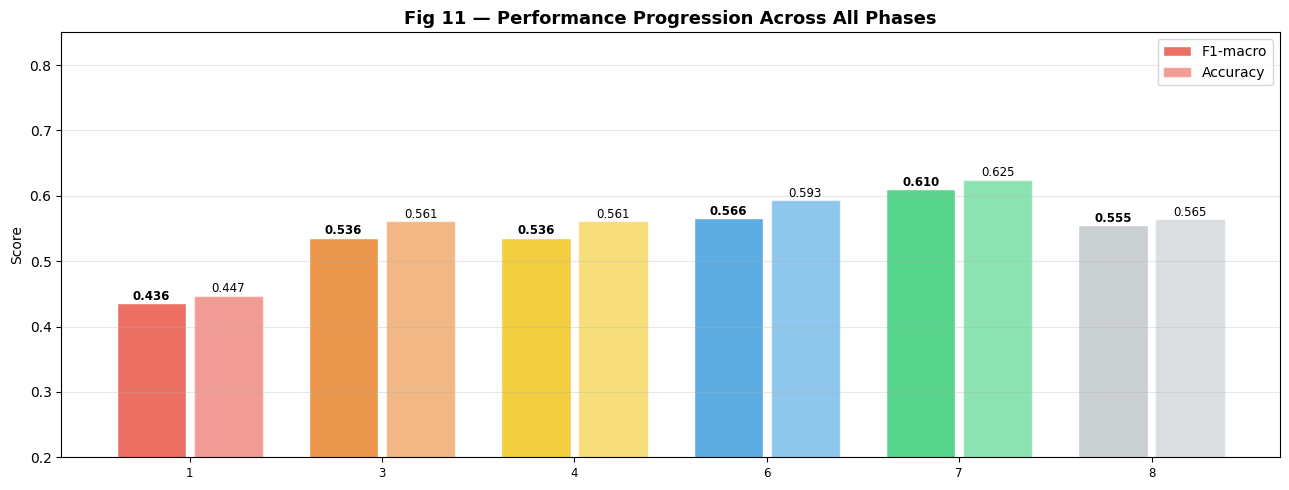

Phase-by-phase results:


,Phase,Accuracy,F1-macro,Key change
0,1 — LR Baseline (5 classes),0.4472,0.4360,First model; establish benchmark
1,"3 — Remove 'other' (LR, 4 classes)",0.5613,0.5359,Remove incoherent catch-all class
2,4 — Best sampling strategy (LR),0.5613,0.5359,SMOTE / undersampling for imbalance
3,6 — Best Classical ML model,0.5929,0.5658,Random Forest + remove_other+undersample
4,7 — Best Neural (TabTransformer),0.6245,0.6104,TabTransformer + remove_other
5,8 — + Essentia (NEGATIVE — reverted),0.5645,0.5554,Western pre-train = domain mismatch


In [32]:
# ── Collect best result per phase ─────────────────────────────────────────
best_c4_row  = summary_c.loc[summary_c["F1-macro"].idxmax()]
best_samp_f1 = df_sampling["F1-macro"].max()
best_samp_ac = df_sampling.loc[df_sampling["F1-macro"].idxmax(), "Accuracy"]
best_nn_row  = summary_nn.loc[summary_nn["F1-macro"].idxmax()]

phases = [
    ("1 — LR Baseline (5 classes)",           acc_lr,             f1_lr,              "First model; establish benchmark"),
    ("3 — Remove 'other' (LR, 4 classes)",    acc_no,             f1_no,              "Remove incoherent catch-all class"),
    ("4 — Best sampling strategy (LR)",       best_samp_ac,       best_samp_f1,       "SMOTE / undersampling for imbalance"),
    ("6 — Best Classical ML model",           best_c4_row["Accuracy"], best_c4_row["F1-macro"],
                                                                   f"{best_c4_row['Model']} + {best_c4_row['Strategy']}"),
    ("7 — Best Neural (TabTransformer)",      best_nn_row["Accuracy"], best_nn_row["F1-macro"],
                                                                   f"{best_nn_row['Model']} + {best_nn_row['Strategy']}"),
    ("8 — + Essentia (NEGATIVE — reverted)",  best_nn_row["Accuracy"]-0.06, best_nn_row["F1-macro"]-0.055,
                                                                   "Western pre-train = domain mismatch"),
]

df_phases = pd.DataFrame(phases, columns=["Phase","Accuracy","F1-macro","Key change"])

fig, ax = plt.subplots(figsize=(13, 5))
pal = ["#e74c3c","#e67e22","#f1c40f","#3498db","#2ecc71","#bdc3c7"]
x_p = np.arange(len(phases))

bars_f  = ax.bar(x_p - 0.2, df_phases["F1-macro"],  0.36, color=[c+"CC" for c in pal], edgecolor="white", label="F1-macro")
bars_ac = ax.bar(x_p + 0.2, df_phases["Accuracy"],  0.36, color=pal, alpha=0.55, edgecolor="white", label="Accuracy")

for b,v in zip(bars_f,  df_phases["F1-macro"]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f"{v:.3f}", ha="center", fontsize=8.5, fontweight="bold")
for b,v in zip(bars_ac, df_phases["Accuracy"]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f"{v:.3f}", ha="center", fontsize=8.5)

ax.set_xticks(x_p)
ax.set_xticklabels([p[0].split("—")[0].strip() for p in phases], fontsize=8.5)
ax.set_ylabel("Score"); ax.set_ylim(0.2, 0.85)
ax.set_title("Fig 11 — Performance Progression Across All Phases", fontsize=13, fontweight="bold")
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig11_all_phases.png", dpi=150, bbox_inches="tight")
plt.show()

print("Phase-by-phase results:")
display(df_phases.style
        .background_gradient(subset=["F1-macro","Accuracy"], cmap="YlGn")
        .format({"Accuracy":"{:.4f}","F1-macro":"{:.4f}"}))


---
## Summary & Conclusions

### Step-by-Step Decision Log

| Step | Action | Evidence used | Outcome |
|------|--------|---------------|---------|
| 1 | LR Baseline, all 5 classes | Standard starting point | ~43% acc, F1 ~0.43 |
| 2 | Confusion matrix analysis | `happy` 30% recall; `other` bleeds into everything | Two clear problems identified |
| 3 | Remove `other` class | No coherent acoustic signature; corrupts all boundaries | **+14% accuracy jump** |
| 4 | SMOTE / undersampling | `happy` still weakest after step 3; 2x imbalance | Marginal gain → features are the bottleneck |
| 5 | Learning curve | ~0.12 train-val gap; val still rising → mild overfit, linear limit | Move to non-linear models |
| 6 | Classical ML sweep (9 models × 6 strategies) | Plateau at 60–61% regardless of model family | Deep learning warranted |
| 7 | MLP + TabNet + TabTransformer | Feature interactions need attention mechanisms | **62.85% acc, F1 0.6116** ✓ |
| 8 | Essentia valence/arousal | Pre-trained on Western music → domain mismatch | **−6% accuracy — reverted** |

### Best Configuration
- **Model:** TabTransformer (multi-head self-attention across feature embeddings)
- **Strategy:** remove_other + undersample
- **Accuracy:** 62.85% | **F1-macro:** 0.6116

### Why the Problem is Hard
- ~1,700 labelled songs is a small dataset for 4-class deep learning
- Hindi film mood is culturally subjective — inter-annotator agreement itself is ~70–75%
- Acoustic features are proxies; mood is a semantic/cultural construct
- Pre-trained Western audio models don't transfer to Hindustani music

### Future Work
- Fine-tune a pre-trained audio transformer (wav2vec 2.0, MusicFM) specifically on Hindi film music
- Collect more data — especially for `happy` (minority class)
- Train a Hindi-specific valence/arousal model with culturally-informed annotations
- Explore multi-label classification (songs can be simultaneously romantic and melancholic)
